# Week9 - Ensemble Assignment

1. Train Model
* Train-test split
* Train a random forest model
* Try bagging & boosting algorithms
* Evaluate the models
* Explain findings
* Save the best model

2. In a new notebook, load the saved model
* Evaluate your results data with `generate_dataset_prod()`

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [35]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

def generate_dataset(sample=1000, random_state=42):   
    X, y = make_circles(n_samples=sample,noise=0.1, random_state=random_state)
    df1 = pd.DataFrame(X)
    df1['y'] = y
    
    X1, y1 = make_moons(n_samples=sample, noise=0.1, random_state=random_state)
    df2 = pd.DataFrame(X1)
    df2['y'] = y
    
    df = pd.concat([df1, df2])
    df = df.sample(frac=1).reset_index(drop=True)
    return df[[0,1]].to_numpy(), df.y

# production data - use this in the new notebook with the saved model
def generate_dataset_prod(sample=300, random_state=60):   
    X, y = make_circles(n_samples=sample,noise=0.1, random_state=random_state)
    df1 = pd.DataFrame(X)
    df1['y'] = y
    
    X1, y1 = make_moons(n_samples=sample, noise=0.1, random_state=random_state)
    df2 = pd.DataFrame(X1)
    df2['y'] = y
    
    df = pd.concat([df1, df2])
    df = df.sample(frac=1).reset_index(drop=True)
    return df[[0,1]].to_numpy(), df.y

In [36]:
X, y = generate_dataset()

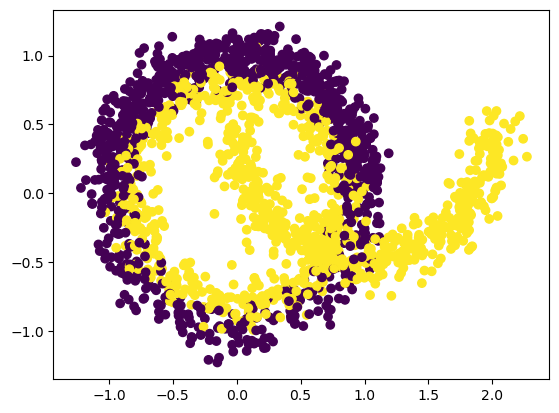

In [37]:
plt.scatter(X[:,0], X[:,1],c=y)
plt.show()

In [38]:
y.value_counts()

y
1    1000
0    1000
Name: count, dtype: int64

In [39]:
#train-test Split
from sklearn.model_selection import train_test_split
#splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#checking dataset sizes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1600, 2)
Testing data shape: (400, 2)


In [40]:
#training random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#creating the random forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# training the model
rf_model.fit(X_train, y_train)
# making predictions
rf_pred = rf_model.predict(X_test)
# evaluating the model
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.855

Confusion Matrix:
[[165  27]
 [ 31 177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       192
           1       0.87      0.85      0.86       208

    accuracy                           0.85       400
   macro avg       0.85      0.86      0.85       400
weighted avg       0.86      0.85      0.86       400



In [41]:
#train Bagging Model
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
#creating bagging model
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
#training model
bag_model.fit(X_train, y_train)
#making predictions
bag_pred = bag_model.predict(X_test)
#evaluating model
bag_accuracy = accuracy_score(y_test, bag_pred)

print("Bagging Accuracy:", bag_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, bag_pred))
print("\nClassification Report:")
print(classification_report(y_test, bag_pred))

Bagging Accuracy: 0.845

Confusion Matrix:
[[164  28]
 [ 34 174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       192
           1       0.86      0.84      0.85       208

    accuracy                           0.84       400
   macro avg       0.84      0.85      0.84       400
weighted avg       0.85      0.84      0.85       400



In [49]:
#training boosting model 
from sklearn.ensemble import AdaBoostClassifier
#creating boosting model
boost_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
#training model
boost_model.fit(X_train, y_train)
#making predictions
boost_pred = boost_model.predict(X_test)
#evaluating model
boost_accuracy = accuracy_score(y_test, boost_pred)
print("Boosting Accuracy:", boost_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, boost_pred))
print("\nClassification Report:")
print(classification_report(y_test, boost_pred))

Boosting Accuracy: 0.8375

Confusion Matrix:
[[171  21]
 [ 44 164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       192
           1       0.89      0.79      0.83       208

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [50]:
#Compareing model performances
print("Random Forest Accuracy:", rf_accuracy)
print("Bagging Accuracy:", bag_accuracy)
print("Boosting Accuracy:", boost_accuracy)

Random Forest Accuracy: 0.855
Bagging Accuracy: 0.845
Boosting Accuracy: 0.8375


EXPLANTION-

in this assignment three ensemble models are trained and evaluated: random forest bagging and AdaBoost after we split the dataset into training and testing sets, each model was trained on the training data and tested using the test data the random forest and bagging models both achieved the highest accuracy of 0.85 while AdaBoost achieved a slightly lower accuracy of 0.8375 Random Forest performed well because it combines multiple decision trees using both bootstrap sampling and random feature selection which helps reduce overfitting and improves prediction stability bagging also reduces variance by averaging predictions from multiple decision trees trained on different samples of the dataset AdaBoost works sequentially by focusing more on previously misclassified observations but in this case it performed slightly worse than the other two models hence random forest was selected as the best model because it provided strong and stable performance across both classes



In [52]:
#saveing best model which is random forest
import joblib
joblib.dump(rf_model, "best_model.pkl")
print("Best model saved successfully!")

Best model saved successfully!


In [53]:
import os
os.path.getsize("best_model.pkl")

2958553